In [1]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import create_mnist_dataloader, SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

In [2]:
N = 1024
dataset = SyntheticDatasetV3(n = N, num_samples=2**15, seed = 0)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=2**12, shuffle=True)


In [3]:
from mps.trainer.smps_trainer import smps_train
from mps.simple_mps import SimpleMPS
import copy
# smps_params = torch.load("smps_2000.pth", weights_only=False)

chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"
eps = 0.1 / np.sqrt(N)
smps = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps)

smps.mps.params[0].data[:] = torch.tensor([ [0, 1], [1, 0] ])
for i in range(1, len(smps.mps.params) - 1):
    smps.mps.params[1].data[:] = torch.stack((torch.eye(2), ) * 2).permute(1, 0, 2)


Path is not set, setting...
Found the path
Initialized MPS with random matrices


In [4]:
from mps.trainer.smps_trainer import smps_train
import copy

epochs = 100
lr = 0.0001
logsoftmax = torch.nn.LogSoftmax(dim=-1)
nnloss = torch.nn.NLLLoss(reduction="mean")
opt_smps = torch.optim.Adam(smps.parameters(), lr=lr)
smps_losses = []
smps.train()
print(f"\n=== Training SimpleMPS for {epochs} epoch(s)... ===")
for epoch in range(epochs):
    total_loss = 0.0
    total_samples = 0
    total_correct = 0
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        data = data.permute(1, 0, 2)  # [batch, N, 2] → [N, batch, 2]
        opt_smps.zero_grad()
        outputs = smps(data)
        outputs = torch.abs(outputs)
        outputs = logsoftmax(outputs)
        loss = nnloss(outputs, target)
        loss.backward()
        
        # Print the norm of the gradients for 10 equally split indices
        params = list(smps.parameters())
        num_params = len(params)
        indices = [int(i * num_params / 10) for i in range(10)]
        grad_norms = [f"Gradient norm for parameter {idx}: {params[idx].grad.norm().item():.6f}" for idx in indices if params[idx].grad is not None]
        print(" | ".join(grad_norms))
        
        opt_smps.step()
        bs = target.size(0)
        total_loss += loss.item() * bs
        total_samples += bs
        preds = outputs.argmax(dim=-1)
        acc = (preds == target).float().sum().item()
        total_correct += acc
        print(f"[SimpleMPS] Epoch {epoch+1}, Step {batch_idx+1}/{len(dataloader)} | Loss: {loss.item():.6f} | Acc: {acc/bs:.2%}")
    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    smps_losses.append(epoch_loss)
    print(f"[SimpleMPS] Epoch {epoch+1} | Loss: {epoch_loss:.6f} | Acc: {epoch_acc:.2%}")


=== Training SimpleMPS for 100 epoch(s)... ===
Gradient norm for parameter 0: 0.197130 | Gradient norm for parameter 102: 0.139207 | Gradient norm for parameter 205: 0.139806 | Gradient norm for parameter 307: 0.139155 | Gradient norm for parameter 410: 0.139850 | Gradient norm for parameter 512: 0.140144 | Gradient norm for parameter 615: 0.139788 | Gradient norm for parameter 717: 0.140318 | Gradient norm for parameter 820: 0.139678 | Gradient norm for parameter 922: 0.139495
[SimpleMPS] Epoch 1, Step 1/8 | Loss: 0.309352 | Acc: 100.00%
Gradient norm for parameter 0: 0.242054 | Gradient norm for parameter 102: 0.172434 | Gradient norm for parameter 205: 0.171932 | Gradient norm for parameter 307: 0.170947 | Gradient norm for parameter 410: 0.171120 | Gradient norm for parameter 512: 0.169949 | Gradient norm for parameter 615: 0.169062 | Gradient norm for parameter 717: 0.169054 | Gradient norm for parameter 820: 0.169764 | Gradient norm for parameter 922: 0.168291
[SimpleMPS] Epoch 

KeyboardInterrupt: 

In [17]:
from mps import tpcp_mps
from mps.trainer.utils import calculate_accuracy, focal_loss, mean_risk
# --- Step 2: Build and Prepare TPCP ---
tpcp = tpcp_mps.MPSTPCP(
    N,
    K=1,
    d=2,
    enable_r=True,
    with_identity=False,
    manifold=tpcp_mps.ManifoldType.EXACT,
)
tpcp.train()
tpcp.set_canonical_mps(smps)

torch.save(tpcp.state_dict(), f"pth/tpcp_v3_0.pth")
# state = torch.load("pth/tpcp_v3_1024.pth")
# tpcp.load_state_dict(state)

In [ ]:
def update_weights_min(W_now, w_min):
    W_new = W_now.clone()
    W_new = torch.min(W_now, w_min)
    return W_new

logsoftmax = torch.nn.LogSoftmax(dim=-1)
nnloss = torch.nn.NLLLoss(reduction="mean")

W = torch.zeros(tpcp.L, 2, dtype=torch.float64)
W[:, 0] = 1 
W[:, 1] = 0.0015
tpcp.initialize_W(W)
# W_now = tpcp.W.clone()
# W_new = update_weights(W_now, 0.01)
# tpcp.initialize_W(W_new)
# torch.save(tpcp.state_dict(), "tpcp_state_dict_new.pth")
# 
# --- Step 3: Determine lambda_final Using the Initial Loss Value ---
data_batch, target_batch = next(iter(dataloader))
initial_probs, reg = tpcp(data_batch, return_probs=True, return_reg=True)
initial_accuracy = calculate_accuracy(initial_probs[:, 0], target_batch)
srpq = torch.exp(-reg)
sr_sys = torch.exp(-reg*N)
print("srpq: ", srpq)
print("success rate : ", sr_sys)
print(f"Initial accuracy: {initial_accuracy.item():.2%}")
loss = focal_loss(initial_probs, target_batch, gamma=0.0, alpha = 0.5)
# ls = logsoftmax(initial_probs)
# loss = nnloss(ls, target_batch)
print(f"Initial loss: {loss.item()}")

srpq:  tensor(0.5007, dtype=torch.float64, grad_fn=<ExpBackward0>)
success rate :  tensor(2.5598e-308, dtype=torch.float64, grad_fn=<ExpBackward0>)
Initial accuracy: 99.95%
Initial loss: 0.25179769328451823


In [19]:
import os 
# Define the file path for storing epoch metrics
epoch_metrics_file_path = "csv/tpcp_v3_epoch_metrics_1024.csv"
# Define the file path for storing iteration metrics
iter_metrics_file_path = "csv/tpcp_v3_iter_metrics_1024.csv"

# Initialize the epoch metrics file with headers if it doesn't exist
if not os.path.exists(epoch_metrics_file_path):
    print("Epoch metrics file does not exist. Creating it.")
    with open(epoch_metrics_file_path, 'w') as f:
        f.write("w_value,epoch,avg_loss,avg_loss_with_reg,avg_acc,avg_srpq,avg_reg\n")

# Initialize the iteration metrics file with headers if it doesn't exist
if not os.path.exists(iter_metrics_file_path):
    print("Iteration metrics file does not exist. Creating it.")
    with open(iter_metrics_file_path, 'w') as f:
        f.write("w_value,epoch,iter,loss0,reg,loss,acc,srpq\n")

In [49]:
from mps.radam import RiemannianAdam
from geoopt import optim
from mps.StiefelOptimizers import StiefelAdam, StiefelSGD
import torch

def update_weights_min(W_now, w_min):
    W_new = W_now.clone()
    W_new = torch.maximum(W_now, torch.tensor(w_min))
    return W_new

# W = torch.zeros(tpcp.L, 2, dtype=torch.float64)
w_value = 0.004
# W[:, 0] = 1 
# W[:, 1] = w_value
W = update_weights_min(tpcp.W, w_value)
tpcp.initialize_W(W)
# 
# --- Step 3: Determine lambda_final Using the Initial Loss Value ---
data_batch, target_batch = next(iter(dataloader))
initial_probs, reg = tpcp(data_batch, return_probs=True, return_reg=True)
initial_accuracy = calculate_accuracy(initial_probs[:, 0], target_batch)
srpq = torch.exp(-reg)
sr_sys = torch.exp(-reg*N)
print("srpq: ", srpq)
print("success rate : ", sr_sys)
print(f"Initial accuracy: {initial_accuracy.item():.2%}")
loss = focal_loss(initial_probs, target_batch, gamma=0.0, alpha = 0.5)
print(f"Initial loss: {loss.item()}")
torch.save(tpcp.state_dict(), f"pth/tpcp_v3_1024_first_w_{w_value}.pth")


srpq:  tensor(0.5047, dtype=torch.float64, grad_fn=<ExpBackward0>)
success rate :  tensor(7.7025e-305, dtype=torch.float64, grad_fn=<ExpBackward0>)
Initial accuracy: 64.67%
Initial loss: 0.3365859255834806


In [46]:
lr = 0.001
optimizer = RiemannianAdam(tpcp.kraus_ops.parameters(), lr=lr)
optimizer_weight = torch.optim.Adam([tpcp.r, tpcp.W], lr=lr*0.05)
tpcp.W.requires_grad = True
tpcp.r.requires_grad = True

In [47]:
from mps.trainer.adaptive_mpsae_trainer import RiemannianAdam
from geoopt import optim
from mps.StiefelOptimizers import StiefelAdam, StiefelSGD
import torch
import pandas as pd
import os


clambda = 80
epochs = 50

for epoch in range(epochs):
    epoch_loss_sum = 0.0
    epoch_acc_sum = 0.0
    epoch_loss_with_reg_sum = 0.0
    epoch_srpq_sum = 0.0
    epoch_reg_sum = 0.0
    epoch_w = 0.0
    total_samples = 0

    for iter_num, (data, target) in enumerate(dataloader, start=1):
        optimizer.zero_grad()
        optimizer_weight.zero_grad()
        outputs, reg = tpcp(data, return_probs=True, return_reg=True)
        loss0 = focal_loss(outputs, target, gamma=0.0, alpha = 0.5)
        risk = mean_risk(outputs, target)
        # ls = logsoftmax(outputs)
        # loss0 = nnloss(ls, target)
        loss = loss0 + clambda * reg

        loss.backward()

        optimizer.step()
        optimizer_weight.step()

        tpcp.proj_stiefel(check_on_manifold=True, print_log=False, rtol=1e-3)
        tpcp.normalize_w_and_r()

        acc = calculate_accuracy(outputs[:, 0], target)
        srpq = torch.exp(-reg)

        bs = target.size(0)
        epoch_loss_sum += loss0.item() * bs
        epoch_loss_with_reg_sum += loss.item() * bs
        total_samples += bs
        epoch_acc_sum += acc.item() * bs
        epoch_srpq_sum += srpq.item() * bs
        epoch_reg_sum += reg.item() * bs
        epoch_w += tpcp.W.data[:, 1].mean().item() * bs
        # Log iteration metrics
        print(f"Epoch {epoch+1}, Iter {iter_num}, Loss0: {loss0.item():.6f}, reg: {reg.item():.6f}, Loss: {loss.item():.6f}, Acc: {acc.item():.2%}, SRPQ: {srpq.item():.6e}, Risk: {risk.item():.6f}, W: {tpcp.W.data[:, 1].mean().item():.6f}")

        # Write iteration metrics to file
        with open(iter_metrics_file_path, 'a') as f:
            f.write(f"{w_value},{epoch+1},{iter_num},{loss0.item():.6f},{reg.item():.6f},{loss.item():.6f},{acc.item():.6f},{srpq.item():.6e}\n")

    # End of epoch: compute averages.
    avg_loss = epoch_loss_sum / total_samples
    avg_loss_with_reg = epoch_loss_with_reg_sum / total_samples
    avg_acc = epoch_acc_sum / total_samples
    avg_srpq = epoch_srpq_sum / total_samples
    avg_reg = epoch_reg_sum / total_samples
    avg_w = epoch_w / total_samples

    # Log epoch metrics
    print(f"Epoch {epoch+1} Summary | Avg Loss: {avg_loss:.6f} | Avg Loss+Reg: {avg_loss_with_reg:.6f} | Acc: {avg_acc:.2%} | SRPQ: {avg_srpq:.6f} | Reg: {avg_reg:.6f} | W: {avg_w:.6f}")


    # Write epoch metrics to file
    with open(epoch_metrics_file_path, 'a') as f:
        f.write(f"{w_value},{epoch+1},{avg_loss:.6f},{avg_loss_with_reg:.6f},{avg_acc:.6f},{avg_srpq:.6f},{avg_reg:.6f},{avg_w:.6f}\n")
    
    W_now = tpcp.W.clone()
    torch.save(tpcp.state_dict(), f"pth/tpcp_v3_1024_end.pth")



Epoch 1, Iter 1, Loss0: 0.188788, reg: 0.687101, Loss: 55.156844, Acc: 100.00%, SRPQ: 5.030324e-01, Risk: 0.313523, W: 0.006050
Epoch 1, Iter 2, Loss0: 0.224493, reg: 0.687110, Loss: 55.193255, Acc: 99.83%, SRPQ: 5.030280e-01, Risk: 0.360310, W: 0.006055
Epoch 1, Iter 3, Loss0: 0.182900, reg: 0.687113, Loss: 55.151918, Acc: 100.00%, SRPQ: 5.030264e-01, Risk: 0.305047, W: 0.006059
Epoch 1, Iter 4, Loss0: 0.185142, reg: 0.687116, Loss: 55.154382, Acc: 100.00%, SRPQ: 5.030250e-01, Risk: 0.307996, W: 0.006063
Epoch 1, Iter 5, Loss0: 0.192079, reg: 0.687114, Loss: 55.161173, Acc: 99.98%, SRPQ: 5.030259e-01, Risk: 0.317327, W: 0.006067
Epoch 1, Iter 6, Loss0: 0.176235, reg: 0.687111, Loss: 55.145079, Acc: 100.00%, SRPQ: 5.030274e-01, Risk: 0.295676, W: 0.006071
Epoch 1, Iter 7, Loss0: 0.158119, reg: 0.687109, Loss: 55.126859, Acc: 100.00%, SRPQ: 5.030281e-01, Risk: 0.269948, W: 0.006074
Epoch 1, Iter 8, Loss0: 0.151981, reg: 0.687120, Loss: 55.121572, Acc: 100.00%, SRPQ: 5.030227e-01, Risk: 

KeyboardInterrupt: 

In [23]:
df = pd.read_csv("iter_metrics.csv")

In [29]:
df

,epoch,iter,loss0,reg,loss,acc,srpq
0,1,1,0.024545,0.693048,6.955023,1.000000,0.500050
1,1,2,0.595348,0.693149,7.526838,0.000000,0.499999
2,1,3,0.047004,0.693080,6.977806,1.000000,0.500034
3,1,4,0.109947,0.693104,7.040985,1.000000,0.500022
4,1,5,0.355163,0.693071,7.285869,0.480469,0.500038
...,...,...,...,...,...,...,...
1065,2,13,0.000022,0.000003,0.000299,1.000000,0.999997
1066,2,14,0.000014,0.000003,0.000270,1.000000,0.999997
1067,2,15,0.000013,0.000002,0.000151,1.000000,0.999999
1068,2,16,0.000014,0.000001,0.000120,1.000000,0.999999


<Axes: >

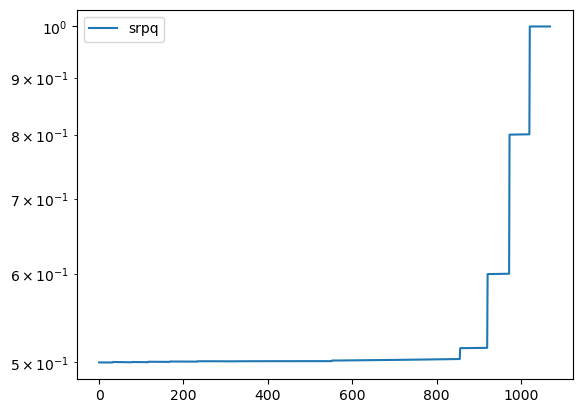

In [33]:
df.plot(y = "srpq", logy=True)

In [136]:
i = 1
x = data_batch[i]
num_K = tpcp.K

rho0 = torch.einsum("i, j->ij", x[0], x[0].conj())
rho1 = torch.einsum("i, j->ij", x[1], x[1].conj())
rho_in = torch.einsum("ij,kl->ikjl", rho0, rho1).reshape(4, 4)
K = tpcp.kraus_ops[0].data.reshape(num_K, 4, 4)
rho_k_out = torch.einsum("kij, jl, kml->im", K, rho_in, K.conj()).reshape(2, 2, 2, 2)
#partial trace
rho_k_out = torch.einsum("ijil -> jl", rho_k_out)

for k in range(1, len(tpcp.kraus_ops.kraus_ops)):
    K = tpcp.kraus_ops[k].data.reshape(num_K, 4, 4)
    rho_new = torch.einsum("i, j->ij", x[k+1], x[k+1].conj())
    rho_k_in = torch.einsum("ij,kl->ikjl", rho_k_out, rho_new).reshape(4, 4)
    rho_k_out = torch.einsum("kij, jl, kml->im", K, rho_k_in, K.conj()).reshape(2, 2, 2, 2)
    rho_last = rho_k_out.data.reshape(4, 4)
    #partial trace
    rho_k_out = torch.einsum("ijil -> jl", rho_k_out)

mes0 = tpcp.r.conj() @ tpcp.pros0 @ tpcp.r.T - tpcp.r.conj() @ tpcp.pros1 @ tpcp.r.T

print(torch.trace(mes0 @ rho_k_out), target_batch[i])
print(tpcp(data_batch[i].unsqueeze(0)), target_batch[i])

tensor(-0.4681, dtype=torch.float64, grad_fn=<TraceBackward0>) tensor(1)
tensor([0.0036], dtype=torch.float64, grad_fn=<SelectBackward0>) tensor(1)


In [452]:
tpcp(data_batch[i].unsqueeze(0)), target_batch[i]

(tensor([0.9907], dtype=torch.float64, grad_fn=<SelectBackward0>), tensor(0))

In [59]:
MPS_list[0].shape

(2, 4)

In [24]:
d = smps.mps.d
chi = smps.mps.chi_max
MPS_list = [core.detach().cpu().numpy() for core in smps.mps.params]
MPS_list[0] = MPS_list[0].reshape(1, d, chi)
d = smps.mps.d


new_MPS_list = [np.zeros(mps_shape.shape) for mps_shape in MPS_list]

A = np.copy(MPS_list[0])

for i in range(len(MPS_list) - 1):

    shapeA = A.shape
    A = A.reshape(A.shape[0] * d, -1)
    
    # Perform SVD
    U, S, V = np.linalg.svd(A, full_matrices=False)

    S = S / np.linalg.norm(S)

    S[4:] = 0 
    U[:, 4:] = 0
    
    # Update chi and R
    chi = len(S)
    R = np.diag(S) @ V[:chi]

    if i < len(MPS_list) - 2:
        A = np.copy(MPS_list[i+1])
        A = np.einsum("ij, jdk->idk", R, A)

    # new_MPS_list.append(U.reshape(shapeA[0], shapeA[1], -1))

    At = U.reshape(shapeA[0], shapeA[1], -1)
    Atshape = At.shape
    new_MPS_list[i][:Atshape[0], :Atshape[1], :Atshape[2]] = At

Af = np.copy(MPS_list[-1])
Af = R @ Af
new_MPS_list[-1][:] = Af

new_MPS_list[0] = new_MPS_list[0].reshape(d, smps.mps.chi_max)
new_MPS_list_tensor = [torch.tensor(new_MPS_list[i]) for i in range(len(new_MPS_list))]

# smps.mps.set_params(new_MPS_list_tensor)
# smps.initialize_MPS()

In [34]:
params = smps.mps.params

chi = 2
smps_new = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps)

params_new = [torch.empty(shape) for shape in smps_new.mps.mps_shapes]

smps.convert_to_canonical()

Path is not set, setting...
Found the path
Initialized MPS with random matrices


AttributeError: 'SimpleMPS' object has no attribute 'convert_to_canonical'

In [52]:
smps_params = torch.load("smps.pth", weights_only=False)

chi = 4
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"
eps = 1e-2
smps = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps)

smps.mps.set_params(smps_params)
smps.initialize_MPS()

d = smps.mps.d
chi = smps.mps.chi_max
MPS_list = [core.detach().cpu().numpy() for core in smps.mps.params]
MPS_list[0] = MPS_list[0].reshape(1, d, chi)
d = smps.mps.d


new_MPS_list = [np.zeros(mps_shape.shape) for mps_shape in MPS_list]

A = np.copy(MPS_list[0])

for i in range(len(MPS_list) - 1):

    shapeA = A.shape
    A = A.reshape(A.shape[0] * d, -1)
    
    # Perform SVD
    U, S, V = np.linalg.svd(A, full_matrices=False)

    U[:, 2:] = 0
    S[2:] = 0
    V[2:, :] = 0
    S = S / np.linalg.norm(S)

    
    # Update chi and R
    chi = len(S)
    R = np.diag(S) @ V[:chi]

    if i < len(MPS_list) - 2:
        A = np.copy(MPS_list[i+1])
        A = np.einsum("ij, jdk->idk", R, A)

    # new_MPS_list.append(U.reshape(shapeA[0], shapeA[1], -1))

    At = U.reshape(shapeA[0], shapeA[1], -1)
    Atshape = At.shape
    new_MPS_list[i][:Atshape[0], :Atshape[1], :Atshape[2]] = At

Af = np.copy(MPS_list[-1])
Af = R @ Af
new_MPS_list[-1][:] = Af

new_MPS_list[0] = new_MPS_list[0].reshape(d, smps.mps.chi_max)
new_MPS_list_tensor = [torch.tensor(new_MPS_list[i]) for i in range(len(new_MPS_list))]

smps.mps.set_params(new_MPS_list_tensor)
smps.initialize_MPS()


Path is not set, setting...
Found the path
Initialized MPS with random matrices
Initialized MPS with random matrices
Initialized MPS with random matrices


In [54]:
new_MPS_list[8][:2, :, :2]

array([[[-6.96452678e-01,  6.11388782e-03],
        [-7.17602633e-01, -6.20796586e-03]],

       [[ 3.50330523e-04, -7.09033352e-01],
        [-7.31461955e-05, -7.05121115e-01]]])

In [261]:
# Try to normalize the MPS
# FIrst prepare the test state
x = torch.randn(N, 2, dtype=smps.mps.dtype, device=smps.mps.device)
# x[:, 0] = 1
x = torch.abs(x)
x = x / x.sum(dim=1).unsqueeze(1)

out = smps(x.reshape(N, 1, 2))
sys_scale = torch.abs(out).sum()
s = sys_scale ** (1 / N)

print(sys_scale)

params = smps.mps.params
params_t = [p.detach().cpu() for p in params]
for i in range(len(params)):
   params_t[i] = params_t[i] * (1 / s)# 

smps.mps.set_params(params_t)
smps.initialize_MPS()

# Check the scale again
out = smps(x.reshape(N, 1, 2))
sys_scale = torch.abs(out).sum()

sys_scale




tensor(7.7383e-77, dtype=torch.float64, grad_fn=<SumBackward0>)
Initialized MPS with random matrices


tensor(1.4198, dtype=torch.float64, grad_fn=<SumBackward0>)

In [262]:
smps(data)

tensor([[0.9485, 1.5121],
        [0.6512, 0.1270],
        [0.9966, 1.5054],
        ...,
        [1.4029, 1.7655],
        [0.6907, 0.2395],
        [0.9409, 1.4726]], dtype=torch.float64, grad_fn=<AbsBackward0>)

In [185]:
1e-78 ** (1 / N)

0.6982324040771714

In [193]:
smps(data)

tensor([[0.5329, 0.9569],
        [0.3981, 0.0426],
        [0.5706, 0.9784],
        ...,
        [0.8310, 1.1142],
        [0.4377, 0.0711],
        [0.5476, 0.9555]], dtype=torch.float64, grad_fn=<AbsBackward0>)